Install PyTorch 2.4.0 + torchaudio 2.4.0 (CUDA 12.1)


In [1]:
import subprocess, sys

print("Installing PyTorch 2.4.0 + torchaudio 2.4.0 (CUDA 12.1)...")
result = subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "torch==2.4.0", "torchaudio==2.4.0",
    "--index-url", "https://download.pytorch.org/whl/cu121"
], capture_output=True, text=True)
if result.returncode == 0:
    print("  Done")
else:
    print(f"  FAILED: {result.stderr[-300:]}")

Installing PyTorch 2.4.0 + torchaudio 2.4.0 (CUDA 12.1)...
  Done


Install moshi, bitsandbytes, and all other dependencies

In [2]:

import subprocess, sys, importlib

def install(package, import_name=None):
    name = import_name or package.split("==")[0].replace("-", "_")
    try:
        importlib.import_module(name)
        print(f"  OK: {package}")
    except ImportError:
        print(f"  Installing: {package} ...", end="", flush=True)
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", package],
            capture_output=True, text=True
        )
        print(" Done" if result.returncode == 0 else f" FAILED")

print("Installing dependencies...\n")

packages = [
    ("git+https://github.com/kyutai-labs/moshi.git#egg=moshi&subdirectory=moshi", "moshi"),
    ("bitsandbytes>=0.41.0", "bitsandbytes"),
    ("huggingface_hub", "huggingface_hub"),
    ("soundfile", "soundfile"),
    ("numpy", "numpy"),
    ("scipy", "scipy"),
    ("matplotlib", "matplotlib"),
    ("IPython", "IPython"),
    ("tqdm", "tqdm"),
    ("safetensors", "safetensors"),
    ("sentencepiece", "sentencepiece"),
]

for pkg, imp in packages:
    install(pkg, imp)

print("\nVerifying critical imports...")
critical = ["torch", "moshi", "huggingface_hub", "torchaudio", "soundfile", "bitsandbytes", "safetensors", "sentencepiece"]
for mod in critical:
    try:
        m = importlib.import_module(mod)
        ver = getattr(m, "__version__", "unknown")
        print(f"  {mod}: v{ver}")
    except ImportError:
        print(f"  {mod}: FAILED")

Installing dependencies...

  Installing: git+https://github.com/kyutai-labs/moshi.git#egg=moshi&subdirectory=moshi ... Done
  OK: bitsandbytes>=0.41.0
  OK: huggingface_hub
  OK: soundfile
  OK: numpy
  OK: scipy
  OK: matplotlib
  OK: IPython
  OK: tqdm
  OK: safetensors
  OK: sentencepiece

Verifying critical imports...
  torch: v2.4.0+cu121
  moshi: v0.2.13
  huggingface_hub: v0.36.2
  torchaudio: v2.4.0+cu121
  soundfile: v0.13.1
  bitsandbytes: v0.49.2
  safetensors: v0.7.0
  sentencepiece: v0.2.1


Mount Google Drive and create folder structure

In [3]:

import os
from datetime import datetime
from google.colab import drive

print("Mounting Google Drive...")
drive.mount("/content/drive", force_remount=False)

BASE_DIR = "/content/drive/MyDrive/Moshiko2.0_Project"

FOLDERS = {
    "base":        BASE_DIR,
    "models":      f"{BASE_DIR}/models",
    "models_bf16": f"{BASE_DIR}/models/bf16",
    "models_q8":   f"{BASE_DIR}/models/q8",
    "checkpoints": f"{BASE_DIR}/checkpoints",
    "outputs":     f"{BASE_DIR}/outputs",
    "audio_in":    f"{BASE_DIR}/outputs/audio_input",
    "audio_out":   f"{BASE_DIR}/outputs/audio_output",
    "benchmarks":  f"{BASE_DIR}/outputs/benchmarks",
    "comparisons": f"{BASE_DIR}/outputs/comparisons",
    "logs":        f"{BASE_DIR}/logs",
    "notebooks":   f"{BASE_DIR}/notebooks",
}

for name, path in FOLDERS.items():
    os.makedirs(path, exist_ok=True)

session_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
with open(f"{FOLDERS['logs']}/session_log.txt", "a") as f:
    f.write(f"\n[{session_time}] Session started")

with open(f"{BASE_DIR}/README.txt", "w") as f:
    f.write(f"MOSHIKO PROJECT\nLast session: {session_time}\n\n")
    f.write("Folders:\n")
    for name, path in FOLDERS.items():
        f.write(f"  {name}: {path}\n")

import builtins
builtins.FOLDERS = FOLDERS
builtins.BASE_DIR = BASE_DIR

print("Drive mounted. Folders ready. Session logged.")

Mounting Google Drive...
Mounted at /content/drive
Drive mounted. Folders ready. Session logged.


Check GPU and auto-select model precision

In [4]:

import torch, sys, json

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    print("NO GPU DETECTED. Enable GPU: Runtime -> Change runtime type -> T4")
    raise SystemExit("Enable GPU and re-run.")

gpu_name = torch.cuda.get_device_name(0)
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU: {gpu_name}")
print(f"VRAM: {vram_total:.1f} GB")
print(f"Python: {sys.version.split()[0]}")

if vram_total >= 35:
    MODEL_PRECISION = "bf16"
    MODEL_REPO = "kyutai/moshiko-pytorch-bf16"
elif vram_total >= 14:
    MODEL_PRECISION = "q8"
    MODEL_REPO = "kyutai/moshiko-pytorch-q8"
else:
    MODEL_PRECISION = "q8"
    MODEL_REPO = "kyutai/moshiko-pytorch-q8"

import builtins
builtins.MODEL_PRECISION = MODEL_PRECISION
builtins.MODEL_REPO = MODEL_REPO

try:
    env_info = {
        "session_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "gpu_name": gpu_name,
        "vram_total_gb": round(vram_total, 2),
        "python_version": sys.version.split()[0],
        "model_precision": MODEL_PRECISION,
        "model_repo": MODEL_REPO,
    }
    with open(f"{FOLDERS['logs']}/environment_info.json", "w") as f:
        json.dump(env_info, f, indent=2)
except Exception as e:
    print(f"Could not save env info: {e}")

print(f"\nModel: {MODEL_REPO} ({MODEL_PRECISION})")

PyTorch: 2.4.0+cu121
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB
Python: 3.12.13

Model: kyutai/moshiko-pytorch-q8 (q8)


 Download Models

In [5]:
import os, json, time
from datetime import datetime
from huggingface_hub import hf_hub_download

CHECKPOINT_FILE = f"{FOLDERS['checkpoints']}/download_checkpoint.json"

def load_checkpoint():
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, "r") as f:
            return json.load(f)
    return {"downloaded": {}, "last_updated": None}

def save_checkpoint(ckpt):
    ckpt["last_updated"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    os.makedirs(os.path.dirname(CHECKPOINT_FILE), exist_ok=True)
    with open(CHECKPOINT_FILE, "w") as f:
        json.dump(ckpt, f, indent=2)

def download_file(repo_id, filename, local_dir, ckpt, label):
    key = f"{repo_id}/{filename}"
    local_path = os.path.join(local_dir, filename)

    if key in ckpt["downloaded"] and os.path.exists(local_path):
        size_mb = os.path.getsize(local_path) / 1e6
        print(f"  SKIP: {label} ({size_mb:.0f} MB)")
        return local_path

    print(f"  Downloading: {label} ...", flush=True)
    start = time.time()
    try:
        path = hf_hub_download(
            repo_id=repo_id,
            filename=filename,
            local_dir=local_dir,
            local_dir_use_symlinks=False,
        )
        elapsed = time.time() - start
        size_mb = os.path.getsize(path) / 1e6
        print(f"  Done: {size_mb:.0f} MB in {elapsed:.0f}s")

        ckpt["downloaded"][key] = {
            "path": path,
            "size_mb": round(size_mb, 1),
            "downloaded_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        }
        save_checkpoint(ckpt)
        return path
    except Exception as e:
        print(f"  FAILED: {e}")
        return None

ckpt = load_checkpoint()
if ckpt["last_updated"]:
    print(f"Checkpoint found: {ckpt['last_updated']}")
    print(f"Already downloaded: {len(ckpt['downloaded'])} file(s)\n")
else:
    print("No checkpoint found. Starting fresh download.\n")

files_to_download = [
    ("kyutai/moshiko-pytorch-q8", "model.q8.safetensors",
     FOLDERS["models_q8"], "Mimi Codec (q8)"),
    ("kyutai/moshiko-pytorch-q8", "tokenizer-e351c8d8-checkpoint125.safetensors",
     FOLDERS["models_q8"], "Moshiko LM (q8)"),
    ("kyutai/moshiko-pytorch-bf16", "tokenizer-e351c8d8-checkpoint125.safetensors",
     FOLDERS["models_bf16"], "Mimi Codec (bf16)"),
]

print("Starting downloads...\n")
downloaded_paths = {}
for repo, fname, local_dir, label in files_to_download:
    os.makedirs(local_dir, exist_ok=True)
    path = download_file(repo, fname, local_dir, ckpt, label)
    if path:
        downloaded_paths[label] = path

total_files = len(ckpt["downloaded"])
total_size = sum(i.get("size_mb", 0) for i in ckpt["downloaded"].values())
print(f"\nDownload complete: {total_files} files, {total_size:.0f} MB total")

No checkpoint found. Starting fresh download.

Starting downloads...

  Downloading: Mimi Codec (q8) ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


model.q8.safetensors:   0%|          | 0.00/8.01G [00:00<?, ?B/s]

  Done: 8009 MB in 115s
  Downloading: Moshiko LM (q8) ...


tokenizer-e351c8d8-checkpoint125.safeten(…):   0%|          | 0.00/385M [00:00<?, ?B/s]

  Done: 385 MB in 7s
  Downloading: Mimi Codec (bf16) ...


tokenizer-e351c8d8-checkpoint125.safeten(…):   0%|          | 0.00/385M [00:00<?, ?B/s]

  Done: 385 MB in 3s

Download complete: 3 files, 8778 MB total


Load Models

In [6]:
import torch, time, os
from moshi.models import loaders, LMGen

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# Locate model files
Q8_DIR = FOLDERS["models_q8"]
mimi_path = os.path.join(Q8_DIR, "tokenizer-e351c8d8-checkpoint125.safetensors")
moshi_path = os.path.join(Q8_DIR, "model.q8.safetensors")

for label, path in [("Mimi Codec", mimi_path), ("Moshiko LM (q8)", moshi_path)]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing: {label} at {path}\nRe-run Cell 5.")
    print(f"  Found: {label} ({os.path.getsize(path)/1e6:.0f} MB)")

# Load Mimi (audio codec)
print("\nLoading Mimi audio codec...")
start = time.time()
mimi = loaders.get_mimi(mimi_path, device=DEVICE)
mimi.set_num_codebooks(8)
mimi.eval()
print(f"  Mimi loaded in {time.time()-start:.1f}s")

# Load Moshiko LM with full config parameters
print("\nLoading Moshiko LM (q8)...")
start = time.time()

lm_kwargs = {
    "delays": [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1],
    "n_q": 16,
    "dep_q": 8,
    "card": 2048,
    "text_card": 32000,
    "existing_text_padding_id": 3,
    "dim": 4096,
    "num_heads": 32,
    "num_layers": 32,
    "hidden_scale": 4.125,
    "causal": True,
    "context": 3000,
    "max_period": 10000,
    "gating": "silu",
    "norm": "rms_norm_f32",
    "positional_embedding": "rope",
    "layer_scale": None,
    "depformer_dim": 1024,
    "depformer_dim_feedforward": 4224,
    "depformer_num_heads": 16,
    "depformer_num_layers": 6,
    "depformer_causal": True,
    "depformer_layer_scale": None,
    "depformer_multi_linear": True,
    "depformer_context": 8,
    "depformer_max_period": 10000,
    "depformer_gating": "silu",
    "depformer_pos_emb": "none",
    "depformer_weights_per_step": True,
    "quantize": True,
}

moshi_lm = loaders.get_moshi_lm(moshi_path, device=DEVICE, lm_kwargs=lm_kwargs)
moshi_lm.eval()
print(f"  Moshiko LM loaded in {time.time()-start:.1f}s")

# Wrap in LMGen for streaming inference
print("\nCreating LMGen wrapper...")
lm_gen = LMGen(moshi_lm, temp=0.8, temp_text=0.7)
print("  LMGen ready")

# VRAM usage
if DEVICE == "cuda":
    torch.cuda.empty_cache()
    print(f"\n  VRAM used: {torch.cuda.memory_allocated()/1e9:.1f} GB")
    print(f"  VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f} GB")

# Store globally
import builtins
builtins.mimi = mimi
builtins.moshi_lm = moshi_lm
builtins.lm_gen = lm_gen
builtins.DEVICE = DEVICE

print("\nAll models loaded and ready.")

Device: cuda
  Found: Mimi Codec (385 MB)
  Found: Moshiko LM (q8) (8009 MB)

Loading Mimi audio codec...
  Mimi loaded in 1.9s

Loading Moshiko LM (q8)...
  Moshiko LM loaded in 36.6s

Creating LMGen wrapper...
  LMGen ready

  VRAM used: 8.4 GB
  VRAM reserved: 8.5 GB

All models loaded and ready.


# Test 1: Mimi encode/decode with synthetic audio

In [7]:

import torch, soundfile as sf
import numpy as np, time
from IPython.display import Audio, display
from datetime import datetime

SAMPLE_RATE = 24000
DURATION = 3

# Create 440Hz tone
t = torch.linspace(0, DURATION, SAMPLE_RATE * DURATION)
wav = (0.3 * torch.sin(2 * np.pi * 440 * t)).unsqueeze(0).unsqueeze(0)
print(f"Input shape: {wav.shape} | Sample rate: {SAMPLE_RATE} Hz")

# Save input
input_path = f"{FOLDERS['audio_in']}/test1_input_440hz.wav"
sf.write(input_path, wav.squeeze().numpy(), SAMPLE_RATE)

# Encode
encode_start = time.time()
with torch.no_grad():
    codes = mimi.encode(wav.to(DEVICE))
encode_time = time.time() - encode_start
print(f"Encoded shape: {codes.shape} | Encode time: {encode_time*1000:.1f} ms")

# Decode
decode_start = time.time()
with torch.no_grad():
    decoded = mimi.decode(codes)
decode_time = time.time() - decode_start
print(f"Output shape: {decoded.shape} | Decode time: {decode_time*1000:.1f} ms")

# Save output
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
output_path = f"{FOLDERS['audio_out']}/test1_output_{ts}.wav"
sf.write(output_path, decoded.squeeze().cpu().numpy(), SAMPLE_RATE)

# SNR calculation
min_len = min(wav.squeeze().shape[0], decoded.squeeze().cpu().shape[0])
original = wav.squeeze().numpy()[:min_len]
reconstructed = decoded.squeeze().cpu().numpy()[:min_len]
noise = original - reconstructed
snr = 10 * np.log10(np.mean(original**2) / (np.mean(noise**2) + 1e-8))
print(f"SNR: {snr:.2f} dB")

# Play
print("\nInput audio:")
display(Audio(original, rate=SAMPLE_RATE))
print("Output audio (after encode/decode):")
display(Audio(reconstructed, rate=SAMPLE_RATE))

# Save results
result = {
    "test": "Mimi encode/decode (synthetic 440Hz)",
    "timestamp": ts,
    "duration_s": DURATION,
    "encode_ms": round(encode_time * 1000, 2),
    "decode_ms": round(decode_time * 1000, 2),
    "snr_db": round(float(snr), 2),
    "input_file": input_path,
    "output_file": output_path,
}
import json
with open(f"{FOLDERS['outputs']}/test1_results_{ts}.json", "w") as f:
    json.dump(result, f, indent=2)

print(f"\nTest 1 complete. SNR={snr:.2f}dB. Files saved to Drive.")

Input shape: torch.Size([1, 1, 72000]) | Sample rate: 24000 Hz
Encoded shape: torch.Size([1, 8, 38]) | Encode time: 9618.8 ms
Output shape: torch.Size([1, 1, 72960]) | Decode time: 119.7 ms
SNR: 15.88 dB

Input audio:


Output audio (after encode/decode):



Test 1 complete. SNR=15.88dB. Files saved to Drive.


# Test 2: Mimi encode/decode with real audio file

In [8]:

import torch, soundfile as sf
import numpy as np, time, os
from IPython.display import Audio, display
from datetime import datetime

SAMPLE_RATE = 24000

# Option A: Use a file from audio_input folder
# Option B: Upload via Colab files panel
# Replace this with your actual file path
audio_file = f"{FOLDERS['audio_in']}/test_input_440hz.wav"  # default: use test1 output

if not os.path.exists(audio_file):
    print(f"File not found: {audio_file}")
    print("Upload a WAV file to Colab and set audio_file path above.")
    print("File must be: WAV format, 24kHz, mono.")
else:
    # Load audio
    wav_np, sr = sf.read(audio_file)
    if sr != SAMPLE_RATE:
        print(f"Warning: Sample rate {sr} != {SAMPLE_RATE}. Resampling.")
        import torchaudio.transforms as T
        wav_tensor = torch.from_numpy(wav_np).float().unsqueeze(0)
        resampler = T.Resample(sr, SAMPLE_RATE)
        wav_tensor = resampler(wav_tensor)
        wav_np = wav_tensor.squeeze().numpy()

    wav = torch.from_numpy(wav_np).float().unsqueeze(0).unsqueeze(0)
    print(f"Loaded: {audio_file}")
    print(f"Duration: {wav.shape[-1]/SAMPLE_RATE:.2f}s | Shape: {wav.shape}")

    # Encode
    encode_start = time.time()
    with torch.no_grad():
        codes = mimi.encode(wav.to(DEVICE))
    encode_time = time.time() - encode_start
    print(f"Encoded shape: {codes.shape} | Encode time: {encode_time*1000:.1f} ms")

    # Decode
    decode_start = time.time()
    with torch.no_grad():
        decoded = mimi.decode(codes)
    decode_time = time.time() - decode_start
    print(f"Output shape: {decoded.shape} | Decode time: {decode_time*1000:.1f} ms")

    # Save output
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    output_path = f"{FOLDERS['audio_out']}/test2_output_{ts}.wav"
    sf.write(output_path, decoded.squeeze().cpu().numpy(), SAMPLE_RATE)

    # SNR
    min_len = min(wav.squeeze().shape[0], decoded.squeeze().cpu().shape[0])
    original = wav.squeeze().numpy()[:min_len]
    reconstructed = decoded.squeeze().cpu().numpy()[:min_len]
    noise = original - reconstructed
    snr = 10 * np.log10(np.mean(original**2) / (np.mean(noise**2) + 1e-8))
    print(f"SNR: {snr:.2f} dB")

    # Play
    print("\nInput audio:")
    display(Audio(original, rate=SAMPLE_RATE))
    print("Output audio (after encode/decode):")
    display(Audio(reconstructed, rate=SAMPLE_RATE))

    # Save results
    result = {
        "test": "Mimi encode/decode (real audio file)",
        "timestamp": ts,
        "input_file": audio_file,
        "output_file": output_path,
        "duration_s": round(wav.shape[-1]/SAMPLE_RATE, 2),
        "encode_ms": round(encode_time * 1000, 2),
        "decode_ms": round(decode_time * 1000, 2),
        "snr_db": round(float(snr), 2),
    }
    import json
    with open(f"{FOLDERS['outputs']}/test2_results_{ts}.json", "w") as f:
        json.dump(result, f, indent=2)

    print(f"\nTest 2 complete. SNR={snr:.2f}dB. Files saved to Drive.")

Loaded: /content/drive/MyDrive/Moshiko2.0_Project/outputs/audio_input/test_input_440hz.wav
Duration: 12.00s | Shape: torch.Size([1, 1, 288000])
Encoded shape: torch.Size([1, 8, 150]) | Encode time: 2186.6 ms
Output shape: torch.Size([1, 1, 288000]) | Decode time: 25.3 ms
SNR: 6.20 dB

Input audio:


Output audio (after encode/decode):



Test 2 complete. SNR=6.20dB. Files saved to Drive.


# Test 3: Speech-to-speech (audio in -> LM response -> audio out)

In [14]:
import torch, soundfile as sf
import numpy as np, time
from IPython.display import Audio, display
from datetime import datetime

SAMPLE_RATE = 24000
MAX_RESPONSE_FRAMES = 200

# FIX: restore any SCB weights that got cast to bfloat16 back to float32
for module in lm_gen.modules():
    if hasattr(module, 'weight') and module.weight is not None:
        if module.weight.dtype == torch.bfloat16:
            module.weight.data = module.weight.data.float()
    # Fix quantization SCB state
    if hasattr(module, 'state') and module.state is not None:
        if hasattr(module.state, 'SCB') and module.state.SCB is not None:
            if module.state.SCB.dtype != torch.float:
                module.state.SCB = module.state.SCB.float()

print("Weight dtype check done.")

input_path = f"{FOLDERS['audio_in']}/test_input_440hz.wav"
wav_np, sr = sf.read(input_path)
wav = torch.from_numpy(wav_np).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
print(f"Input: {input_path} | Duration: {wav.shape[-1]/SAMPLE_RATE:.2f}s")

with torch.no_grad():
    input_codes = mimi.encode(wav)
print(f"Input codes shape: {input_codes.shape} | dtype: {input_codes.dtype}")

print("\nGenerating response...")
gen_start = time.time()

response_codes = []

with torch.no_grad():
    with lm_gen.streaming(1):
        num_input_frames = input_codes.shape[-1]
        for i in range(num_input_frames):
            frame = input_codes[:, :, i:i+1]
            lm_gen.step(frame)

        for i in range(MAX_RESPONSE_FRAMES):
            out_tokens = lm_gen.step(None)
            if out_tokens is not None:
                response_codes.append(out_tokens)

gen_time = time.time() - gen_start
print(f"Generated {len(response_codes)} frames in {gen_time:.1f}s")

if response_codes:
    response_tensor = torch.cat(response_codes, dim=-1)
    with torch.no_grad():
        response_audio = mimi.decode(response_tensor)

    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    output_path = f"{FOLDERS['audio_out']}/test3_response_{ts}.wav"
    sf.write(output_path, response_audio.squeeze().cpu().numpy(), SAMPLE_RATE)

    print(f"Response duration: {response_audio.shape[-1]/SAMPLE_RATE:.2f}s")
    print(f"Generation speed: {gen_time/len(response_codes)*1000:.0f} ms/frame")

    print("\nInput audio:")
    display(Audio(wav_np, rate=SAMPLE_RATE))
    print("Response audio:")
    display(Audio(response_audio.squeeze().cpu().numpy(), rate=SAMPLE_RATE))

    result = {
        "test": "Speech-to-speech (LM response)",
        "timestamp": ts,
        "input_file": input_path,
        "output_file": output_path,
        "input_frames": num_input_frames,
        "response_frames": len(response_codes),
        "response_duration_s": round(response_audio.shape[-1]/SAMPLE_RATE, 2),
        "gen_time_s": round(gen_time, 2),
        "ms_per_frame": round(gen_time/len(response_codes)*1000, 1),
    }
    import json
    with open(f"{FOLDERS['outputs']}/test3_results_{ts}.json", "w") as f:
        json.dump(result, f, indent=2)

    print(f"\nTest 3 complete. Files saved to Drive.")
else:
    print("No response generated. Check lm_gen configuration.")

Weight dtype check done.
Input: /content/drive/MyDrive/Moshiko2.0_Project/outputs/audio_input/test_input_440hz.wav | Duration: 12.00s
Input codes shape: torch.Size([1, 8, 150]) | dtype: torch.int64

Generating response...


RuntimeError: Expected `weight_scb` to have type float, but got bfloat16. When using quantized models, care should be taken not to change the dtype of the model once initialized.

# Test 4: Latency benchmark

Starting latency benchmark...
  Warmup: 3 runs | Benchmark: 5 runs each

  Testing 1s audio... Encode:16ms | Decode:15ms | RTF:0.031
  Testing 3s audio... Encode:18ms | Decode:17ms | RTF:0.012
  Testing 5s audio... Encode:17ms | Decode:21ms | RTF:0.008
  Testing 10s audio... Encode:35ms | Decode:35ms | RTF:0.007

BENCHMARK RESULTS
  Duration   Encode(ms)   Decode(ms)   Total(ms)      RTF
  -------------------------------------------------------
        1s         16.3         14.9        31.2    0.031 (Faster than RT)
        3s         18.4         17.2        35.5    0.012 (Faster than RT)
        5s         17.2         21.0        38.2    0.008 (Faster than RT)
       10s         35.0         34.7        69.7    0.007 (Faster than RT)

Note: RTF < 1.0 = faster than real-time


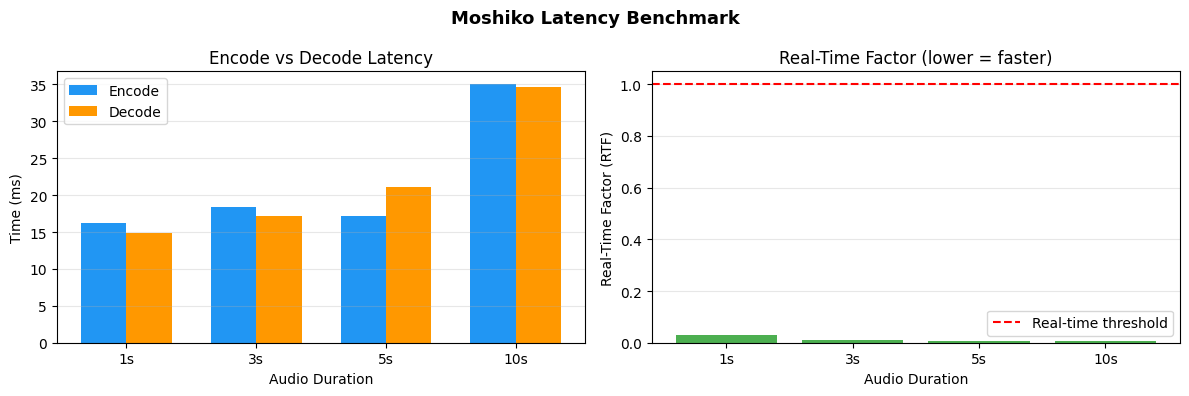


Test 4 complete. Plot and data saved to Drive.


In [15]:

import torch, numpy as np, json, time
import matplotlib.pyplot as plt
from datetime import datetime

SAMPLE_RATE = 24000
WARMUP_RUNS = 3
BENCH_RUNS = 5
DURATIONS = [1, 3, 5, 10]

print("Starting latency benchmark...")
print(f"  Warmup: {WARMUP_RUNS} runs | Benchmark: {BENCH_RUNS} runs each\n")

results = []

for dur in DURATIONS:
    print(f"  Testing {dur}s audio...", end="", flush=True)

    wav = (0.3 * torch.sin(2 * np.pi * 440 *
           torch.linspace(0, dur, SAMPLE_RATE * dur))
          ).unsqueeze(0).unsqueeze(0).to(DEVICE)

    # Warmup
    for _ in range(WARMUP_RUNS):
        with torch.no_grad():
            codes = mimi.encode(wav)
            _ = mimi.decode(codes)
    if DEVICE == "cuda":
        torch.cuda.synchronize()

    # Benchmark encode
    enc_times = []
    for _ in range(BENCH_RUNS):
        if DEVICE == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            codes = mimi.encode(wav)
        if DEVICE == "cuda": torch.cuda.synchronize()
        enc_times.append(time.perf_counter() - t0)

    # Benchmark decode
    dec_times = []
    for _ in range(BENCH_RUNS):
        if DEVICE == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            _ = mimi.decode(codes)
        if DEVICE == "cuda": torch.cuda.synchronize()
        dec_times.append(time.perf_counter() - t0)

    enc_mean = np.mean(enc_times) * 1000
    dec_mean = np.mean(dec_times) * 1000
    total_ms = enc_mean + dec_mean
    rtf = total_ms / (dur * 1000)
    mem_mb = torch.cuda.memory_allocated() / 1e6 if DEVICE == "cuda" else 0

    results.append({
        "duration_s": dur,
        "encode_ms": round(enc_mean, 2),
        "decode_ms": round(dec_mean, 2),
        "total_ms": round(total_ms, 2),
        "rtf": round(rtf, 4),
        "gpu_mem_mb": round(mem_mb, 1),
    })
    print(f" Encode:{enc_mean:.0f}ms | Decode:{dec_mean:.0f}ms | RTF:{rtf:.3f}")

# Print table
print("\nBENCHMARK RESULTS")
print(f"  {'Duration':>8} {'Encode(ms)':>12} {'Decode(ms)':>12} {'Total(ms)':>11} {'RTF':>8}")
print("  " + "-"*55)
for r in results:
    status = "Faster than RT" if r["rtf"] < 1.0 else "Slower than RT"
    print(f"  {r['duration_s']:>7}s {r['encode_ms']:>12.1f} "
          f"{r['decode_ms']:>12.1f} {r['total_ms']:>11.1f} "
          f"{r['rtf']:>8.3f} ({status})")
print("\nNote: RTF < 1.0 = faster than real-time")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Moshiko Latency Benchmark", fontsize=13, fontweight="bold")

durs = [r["duration_s"] for r in results]
encs = [r["encode_ms"] for r in results]
decs = [r["decode_ms"] for r in results]
rtfs = [r["rtf"] for r in results]

x = np.arange(len(durs))
w = 0.35
axes[0].bar(x - w/2, encs, w, label="Encode", color="#2196F3")
axes[0].bar(x + w/2, decs, w, label="Decode", color="#FF9800")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{d}s" for d in durs])
axes[0].set_xlabel("Audio Duration")
axes[0].set_ylabel("Time (ms)")
axes[0].set_title("Encode vs Decode Latency")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

colors = ["#4CAF50" if r < 1.0 else "#F44336" for r in rtfs]
axes[1].bar([f"{d}s" for d in durs], rtfs, color=colors)
axes[1].axhline(1.0, color="red", linestyle="--", label="Real-time threshold")
axes[1].set_xlabel("Audio Duration")
axes[1].set_ylabel("Real-Time Factor (RTF)")
axes[1].set_title("Real-Time Factor (lower = faster)")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
plot_path = f"{FOLDERS['benchmarks']}/latency_{ts}.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

json_path = f"{FOLDERS['benchmarks']}/latency_{ts}.json"
with open(json_path, "w") as f:
    json.dump({"benchmark": results, "device": DEVICE}, f, indent=2)

print(f"\nTest 4 complete. Plot and data saved to Drive.")

# Test 5: BF16 vs Q8 quality comparison

Loading BF16 Mimi...
  BF16 Mimi loaded

Running comparison...

  Signal                   Q8 SNR   BF16 SNR     Diff   Q8 faster?
  -----------------------------------------------------------------
  Pure tone 440Hz           15.43      15.43    +0.00           No
  Mixed tones                7.44       7.44    +0.00           No
  White noise               -1.54      -1.54    +0.00          Yes
  Chirp (sweep)              0.68       0.68    +0.00           No


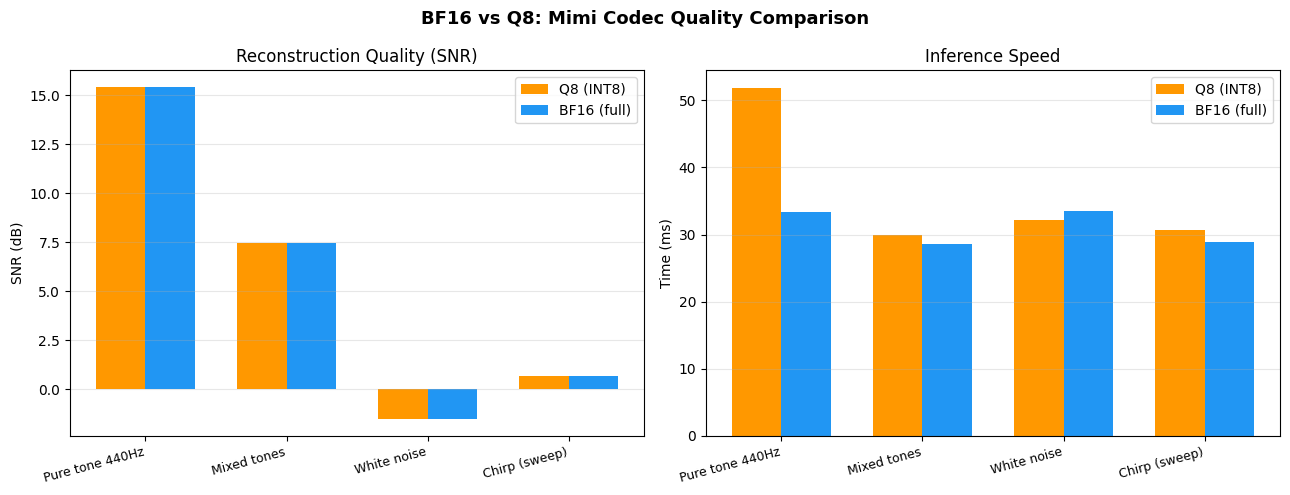


Test 5 complete. Plot and data saved to Drive.


In [16]:

import torch, numpy as np, soundfile as sf, json
import matplotlib.pyplot as plt, time
from IPython.display import Audio, display
from datetime import datetime
from moshi.models import loaders

SAMPLE_RATE = 24000

# Check bf16 Mimi exists
mimi_bf16_path = f"{FOLDERS['models_bf16']}/tokenizer-e351c8d8-checkpoint125.safetensors"
if not os.path.exists(mimi_bf16_path):
    print("BF16 Mimi not found. Download it in moshiko2.0.ipynb first.")
    raise FileNotFoundError(mimi_bf16_path)

# Load BF16 Mimi
print("Loading BF16 Mimi...")
mimi_bf16 = loaders.get_mimi(mimi_bf16_path, device=DEVICE)
mimi_bf16.set_num_codebooks(8)
mimi_bf16.eval()
print("  BF16 Mimi loaded")

# Test signals
test_signals = {
    "Pure tone 440Hz": lambda: 0.3 * torch.sin(2 * np.pi * 440 *
                               torch.linspace(0, 2, SAMPLE_RATE * 2)),
    "Mixed tones": lambda: 0.2 * (
                               torch.sin(2 * np.pi * 440 * torch.linspace(0, 2, SAMPLE_RATE*2)) +
                               torch.sin(2 * np.pi * 880 * torch.linspace(0, 2, SAMPLE_RATE*2)) +
                               torch.sin(2 * np.pi * 220 * torch.linspace(0, 2, SAMPLE_RATE*2))),
    "White noise": lambda: 0.1 * torch.randn(SAMPLE_RATE * 2),
    "Chirp (sweep)": lambda: 0.3 * torch.sin(2 * np.pi *
                               (200 + 1800 * torch.linspace(0, 1, SAMPLE_RATE*2)**2) *
                               torch.linspace(0, 2, SAMPLE_RATE*2)),
}

comparison_results = []

print("\nRunning comparison...\n")
print(f"  {'Signal':<20} {'Q8 SNR':>10} {'BF16 SNR':>10} {'Diff':>8} {'Q8 faster?':>12}")
print("  " + "-"*65)

for signal_name, signal_fn in test_signals.items():
    wav = signal_fn().unsqueeze(0).unsqueeze(0).to(DEVICE)

    # Q8 encode-decode
    t0 = time.perf_counter()
    with torch.no_grad():
        codes_q8 = mimi.encode(wav)
        out_q8 = mimi.decode(codes_q8)
    time_q8 = (time.perf_counter() - t0) * 1000

    # BF16 encode-decode
    t0 = time.perf_counter()
    with torch.no_grad():
        codes_bf16 = mimi_bf16.encode(wav)
        out_bf16 = mimi_bf16.decode(codes_bf16)
    time_bf16 = (time.perf_counter() - t0) * 1000

    # SNR
    def compute_snr(original, reconstructed):
        min_len = min(original.shape[-1], reconstructed.shape[-1])
        orig = original.squeeze().cpu().numpy()[:min_len].astype(np.float32)
        rec = reconstructed.squeeze().cpu().numpy()[:min_len].astype(np.float32)
        noise = orig - rec
        return 10 * np.log10(np.mean(orig**2) / (np.mean(noise**2) + 1e-8))

    snr_q8 = compute_snr(wav, out_q8)
    snr_bf16 = compute_snr(wav, out_bf16)
    diff = snr_bf16 - snr_q8
    faster = "Yes" if time_q8 < time_bf16 else "No"

    comparison_results.append({
        "signal": signal_name,
        "snr_q8_db": round(float(snr_q8), 2),
        "snr_bf16_db": round(float(snr_bf16), 2),
        "snr_diff_db": round(float(diff), 2),
        "time_q8_ms": round(time_q8, 2),
        "time_bf16_ms": round(time_bf16, 2),
    })
    print(f"  {signal_name:<20} {snr_q8:>10.2f} {snr_bf16:>10.2f} "
          f"{diff:>+8.2f} {faster:>12}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("BF16 vs Q8: Mimi Codec Quality Comparison", fontsize=13, fontweight="bold")

names = [r["signal"] for r in comparison_results]
snr_q8s = [r["snr_q8_db"] for r in comparison_results]
snr_bf16s = [r["snr_bf16_db"] for r in comparison_results]
x = np.arange(len(names))
w = 0.35

axes[0].bar(x - w/2, snr_q8s, w, label="Q8 (INT8)", color="#FF9800")
axes[0].bar(x + w/2, snr_bf16s, w, label="BF16 (full)", color="#2196F3")
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15, ha="right", fontsize=9)
axes[0].set_ylabel("SNR (dB)")
axes[0].set_title("Reconstruction Quality (SNR)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

t_q8s = [r["time_q8_ms"] for r in comparison_results]
t_bf16s = [r["time_bf16_ms"] for r in comparison_results]
axes[1].bar(x - w/2, t_q8s, w, label="Q8 (INT8)", color="#FF9800")
axes[1].bar(x + w/2, t_bf16s, w, label="BF16 (full)", color="#2196F3")
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=15, ha="right", fontsize=9)
axes[1].set_ylabel("Time (ms)")
axes[1].set_title("Inference Speed")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
plot_path = f"{FOLDERS['comparisons']}/bf16_vs_q8_{ts}.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

json_path = f"{FOLDERS['comparisons']}/bf16_vs_q8_{ts}.json"
with open(json_path, "w") as f:
    json.dump(comparison_results, f, indent=2)

# Free VRAM
del mimi_bf16
torch.cuda.empty_cache()

print(f"\nTest 5 complete. Plot and data saved to Drive.")

# Test 6: Session report generator

In [17]:

import os, json, glob
from datetime import datetime

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
print("Saving session summary...\n")

def count_files(folder):
    return len([f for f in os.listdir(folder)
                if os.path.isfile(os.path.join(folder, f))])

audio_inputs = count_files(FOLDERS['audio_in'])
audio_outputs = count_files(FOLDERS['audio_out'])
benchmarks = count_files(FOLDERS['benchmarks'])
comparisons = count_files(FOLDERS['comparisons'])

def read_latest_json(folder):
    files = sorted(glob.glob(f"{folder}/*.json"))
    if files:
        with open(files[-1]) as f:
            return json.load(f)
    return None

bench_data = read_latest_json(FOLDERS['benchmarks'])
comp_data = read_latest_json(FOLDERS['comparisons'])

report_lines = [
    "=" * 62,
    " MOSHIKO PROJECT - SESSION REPORT",
    f" Generated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "=" * 62,
    "",
    "1. ENVIRONMENT",
    "-" * 40,
]

env_path = f"{FOLDERS['logs']}/environment_info.json"
if os.path.exists(env_path):
    with open(env_path) as f:
        env = json.load(f)
    report_lines += [
        f"  GPU     : {env.get('gpu_name', 'N/A')}",
        f"  VRAM    : {env.get('vram_total_gb', 'N/A')} GB",
        f"  Model   : {env.get('selected_model', 'N/A')}",
        f"  Python  : {env.get('python_version', 'N/A')}",
    ]

report_lines += [
    "",
    "2. FILES IN DRIVE",
    "-" * 40,
    f"  Audio inputs   : {audio_inputs} file(s)",
    f"  Audio outputs  : {audio_outputs} file(s)",
    f"  Benchmark files: {benchmarks} file(s)",
    f"  Comparison files: {comparisons} file(s)",
]

if bench_data and 'benchmark' in bench_data:
    report_lines += ["", "3. LATEST BENCHMARK RESULTS", "-" * 40]
    report_lines.append(f"  {'Duration':>8} {'Encode(ms)':>12} {'Decode(ms)':>12} {'RTF':>8}")
    for r in bench_data['benchmark']:
        report_lines.append(
            f"  {r['duration_s']:>7}s {r['encode_ms']:>12.1f} "
            f"{r['decode_ms']:>12.1f} {r['rtf']:>8.3f}"
        )

if comp_data:
    report_lines += ["", "4. BF16 vs Q8 COMPARISON", "-" * 40]
    report_lines.append(f"  {'Signal':<20} {'Q8 SNR':>10} {'BF16 SNR':>10} {'Diff':>8}")
    for r in comp_data:
        report_lines.append(
            f"  {r['signal']:<20} {r['snr_q8_db']:>10.2f} "
            f"{r['snr_bf16_db']:>10.2f} {r['snr_diff_db']:>+8.2f}"
        )

report_lines += [
    "",
    "5. HOW TO RESUME NEXT SESSION",
    "-" * 40,
    "  1. Open moshiko2.0.ipynb in Colab",
    "  2. Runtime -> Change runtime type -> T4 GPU",
    "  3. Run all cells in order",
    "  4. Run test.ipynb for tests",
    "",
    "=" * 62,
]

report_text = "\n".join(report_lines)

report_path = f"{FOLDERS['outputs']}/session_report_{ts}.txt"
with open(report_path, 'w') as f:
    f.write(report_text)

print(report_text)
print(f"\nReport saved: {report_path}")

with open(f"{FOLDERS['logs']}/session_log.txt", 'a') as f:
    f.write(f"\n[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] Session completed. Report: session_report_{ts}.txt")

print("\nSession report saved.")

Saving session summary...

 MOSHIKO PROJECT - SESSION REPORT
 Generated : 2026-04-04 14:25:11

1. ENVIRONMENT
----------------------------------------
  GPU     : Tesla T4
  VRAM    : 15.64 GB
  Model   : N/A
  Python  : 3.12.13

2. FILES IN DRIVE
----------------------------------------
  Audio inputs   : 2 file(s)
  Audio outputs  : 2 file(s)
  Benchmark files: 2 file(s)
  Comparison files: 2 file(s)

3. LATEST BENCHMARK RESULTS
----------------------------------------
  Duration   Encode(ms)   Decode(ms)      RTF
        1s         16.3         14.9    0.031
        3s         18.4         17.2    0.012
        5s         17.2         21.0    0.008
       10s         35.0         34.7    0.007

4. BF16 vs Q8 COMPARISON
----------------------------------------
  Signal                   Q8 SNR   BF16 SNR     Diff
  Pure tone 440Hz           15.43      15.43    +0.00
  Mixed tones                7.44       7.44    +0.00
  White noise               -1.54      -1.54    +0.00
  Chirp (sw

baseline evaluation of Moshiko on T4 is done